<a href="https://colab.research.google.com/github/pras1978/fitness-journey-analyzer/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE_PATH = "/content/drive/MyDrive/fitness-journey-analyzer/data"
print("Base path exists:", os.path.exists(BASE_PATH))

Base path exists: True


set all dataset paths

In [3]:
import os

cv_path = os.path.join(BASE_PATH, "cv", "workout_images")
nlp_path = os.path.join(BASE_PATH, "nlp", "sentiment140")
ts_path = os.path.join(BASE_PATH, "timeseries", "fitness_tracking")

print("CV path:", cv_path, os.path.exists(cv_path))
print("NLP path:", nlp_path, os.path.exists(nlp_path))
print("TS path:", ts_path, os.path.exists(ts_path))

CV path: /content/drive/MyDrive/fitness-journey-analyzer/data/cv/workout_images True
NLP path: /content/drive/MyDrive/fitness-journey-analyzer/data/nlp/sentiment140 True
TS path: /content/drive/MyDrive/fitness-journey-analyzer/data/timeseries/fitness_tracking True


check exercise image folders

In [4]:
classes = os.listdir(cv_path)
print("Exercise classes:", classes)
print("Number of classes:", len(classes))

Exercise classes: ['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raises', 'leg extension', 'leg raises', 'plank', 'pull up', 'push up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep dips', 'tricep pushdown']
Number of classes: 22


show one sample image

Sample image path: /content/drive/MyDrive/fitness-journey-analyzer/data/cv/workout_images/barbell biceps curl/barbell biceps curl_3800031.jpg
Image size: (480, 360)


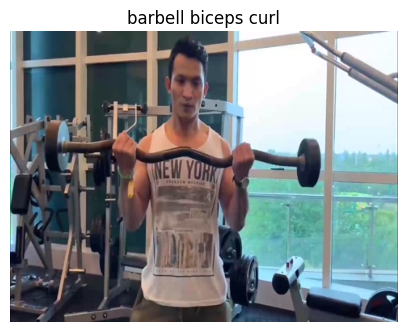

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

sample_class = classes[0]
sample_class_path = os.path.join(cv_path, sample_class)
sample_image_name = os.listdir(sample_class_path)[0]
sample_image_path = os.path.join(sample_class_path, sample_image_name)

img = Image.open(sample_image_path)
print("Sample image path:", sample_image_path)
print("Image size:", img.size)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(sample_class)
plt.axis("off")
plt.show()

count images per exercise

In [6]:
class_counts = {}
for cls in classes:
    cls_path = os.path.join(cv_path, cls)
    class_counts[cls] = len(os.listdir(cls_path))

class_counts

{'barbell biceps curl': 705,
 'bench press': 625,
 'chest fly machine': 527,
 'deadlift': 530,
 'decline bench press': 514,
 'hammer curl': 546,
 'hip thrust': 557,
 'incline bench press': 729,
 'lat pulldown': 646,
 'lateral raises': 843,
 'leg extension': 586,
 'leg raises': 514,
 'plank': 993,
 'pull up': 615,
 'push up': 601,
 'romanian deadlift': 555,
 'russian twist': 522,
 'shoulder press': 512,
 'squat': 742,
 't bar row': 668,
 'tricep dips': 698,
 'tricep pushdown': 625}

plot class distribution

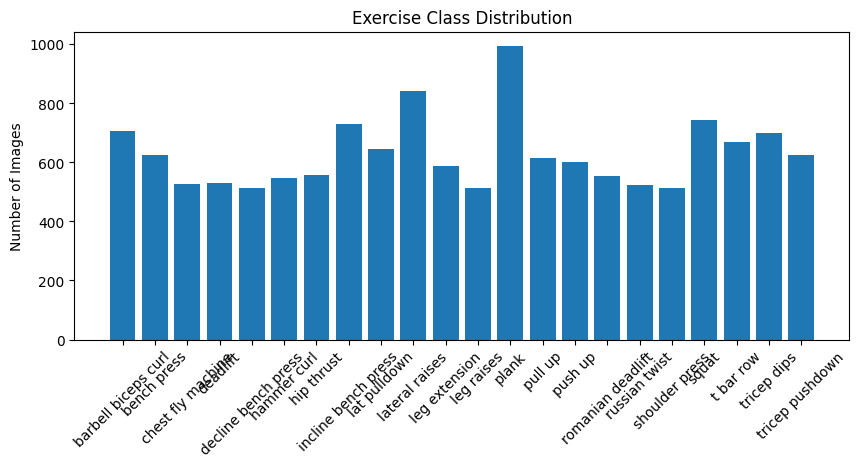

In [7]:
plt.figure(figsize=(10,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Exercise Class Distribution")
plt.ylabel("Number of Images")
plt.show()

load NLP dataset

In [8]:
os.listdir(nlp_path)

['training.csv']

In [9]:
nlp_file = os.path.join(nlp_path, os.listdir(nlp_path)[0])
df_nlp = pd.read_csv(nlp_file, encoding="latin-1", header=None)
df_nlp.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


keep only sentiment and text

In [10]:
df_nlp = df_nlp[[0, 5]]
df_nlp.columns = ["sentiment", "text"]

df_nlp["sentiment"] = df_nlp["sentiment"].replace({0: "negative", 4: "positive"})

df_nlp.head()

,sentiment,text
0,negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,negative,is upset that he can't update his Facebook by ...
2,negative,@Kenichan I dived many times for the ball. Man...
3,negative,my whole body feels itchy and like its on fire
4,negative,"@nationwideclass no, it's not behaving at all...."


sentiment distribution

In [11]:
df_nlp["sentiment"].value_counts()

,count
sentiment,
negative,800000
positive,800000


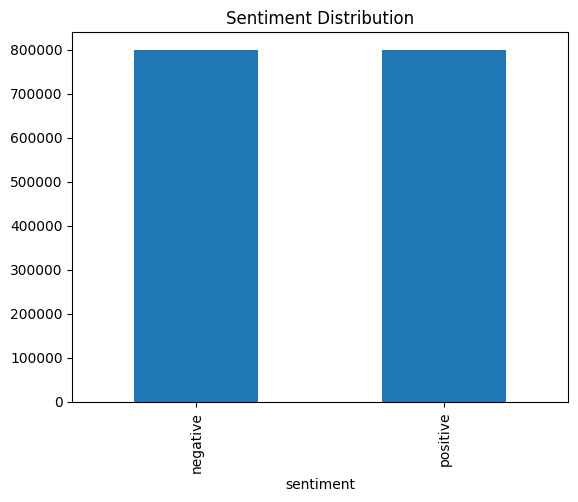

In [12]:
df_nlp["sentiment"].value_counts().plot(kind="bar", title="Sentiment Distribution")
plt.show()

load time-series dataset

In [22]:
os.listdir(ts_path)

['fitness_data.csv', '.ipynb_checkpoints']

In [23]:
ts_file = os.path.join(ts_path, os.listdir(ts_path)[0])
df_ts = pd.read_csv(ts_file)
df_ts.head()

,User_ID,Full Name,Date,Age,Gender,Height (cm),Weight (kg),Steps_Taken,Calories_Burned,Hours_Slept,Water_Intake (Liters),Active_Minutes,Heart_Rate (bpm),Workout_Type,Stress_Level (1-10),Mood
0,1,Sara Martinez,2023-01-01 00:00:00,19,Female,191,80,11405,1862,7.021201,3.440508,80.0,84.0,Yoga,2,Happy
1,1,Sara Martinez,2023-01-02 00:00:00,19,Female,191,80,7010,1806,NaN,3.103590,47.0,72.0,Cardio,9,Neutral
2,1,Sara Martinez,2023-01-03 00:00:00,19,Female,191,80,18942,2274,8.167817,3.814843,46.0,85.0,Yoga,6,Sad
3,1,Sara Martinez,2023-01-04 00:00:00,19,Female,191,80,13778,2656,7.453552,3.508636,105.0,77.0,Yoga,2,Sad
4,1,Sara Martinez,2023-01-05 00:00:00,19,Female,191,80,10247,3571,5.132654,NaN,53.0,61.0,Yoga,8,Sad


inspect columns

In [24]:
print(df_ts.columns.tolist())
print(df_ts.shape)
df_ts.isnull().sum()

['User_ID', 'Full Name', 'Date', 'Age', 'Gender', 'Height (cm)', 'Weight (kg)', 'Steps_Taken', 'Calories_Burned', 'Hours_Slept', 'Water_Intake (Liters)', 'Active_Minutes', 'Heart_Rate (bpm)', 'Workout_Type', 'Stress_Level (1-10)', 'Mood']
(36500, 16)


,0
User_ID,0
Full Name,0
Date,0
Age,0
Gender,0
Height (cm),0
Weight (kg),0
Steps_Taken,0
Calories_Burned,0
Hours_Slept,3659


identify date column and plot one trend

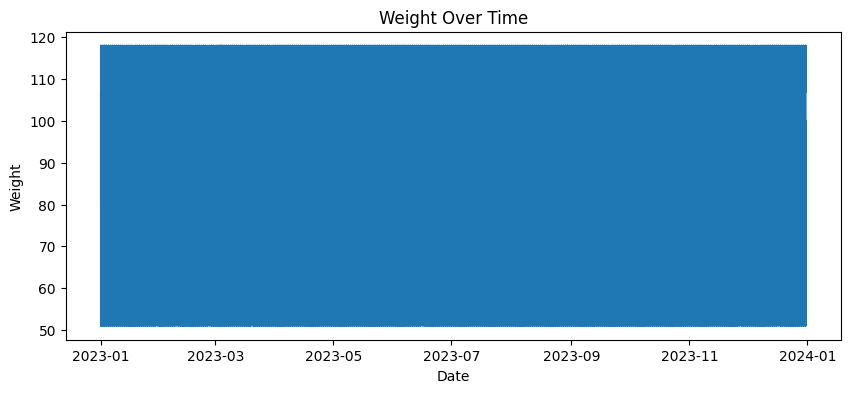

In [26]:
df_ts["Date"] = pd.to_datetime(df_ts["Date"])
df_ts = df_ts.sort_values("Date")

plt.figure(figsize=(10,4))
plt.plot(df_ts["Date"], df_ts["Weight (kg)"])
plt.title("Weight Over Time")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.show()